In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import math
import os

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("titanic.csv")

In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
# checking for the data types
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [9]:
df.shape

(891, 12)

In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


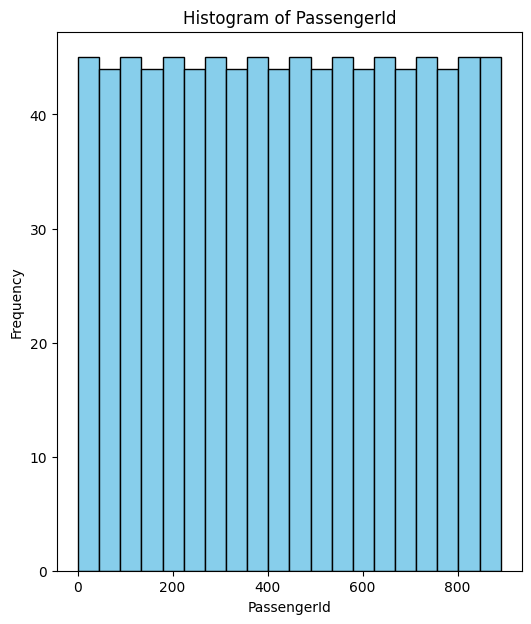

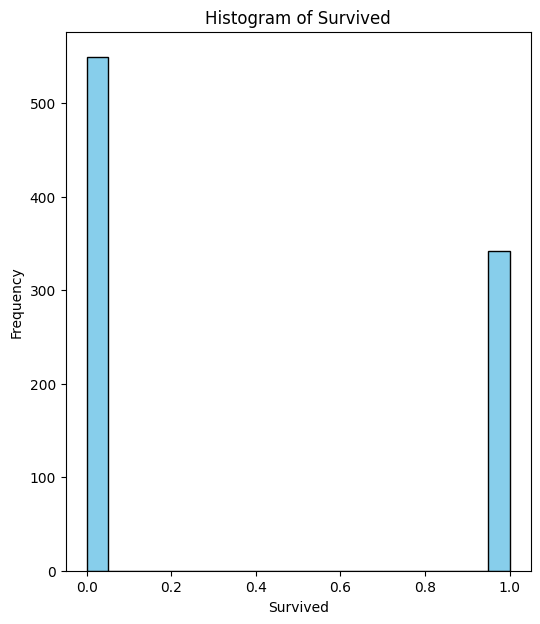

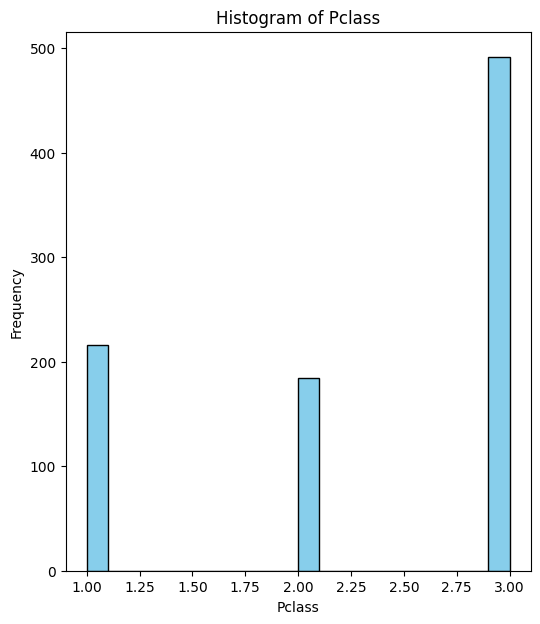

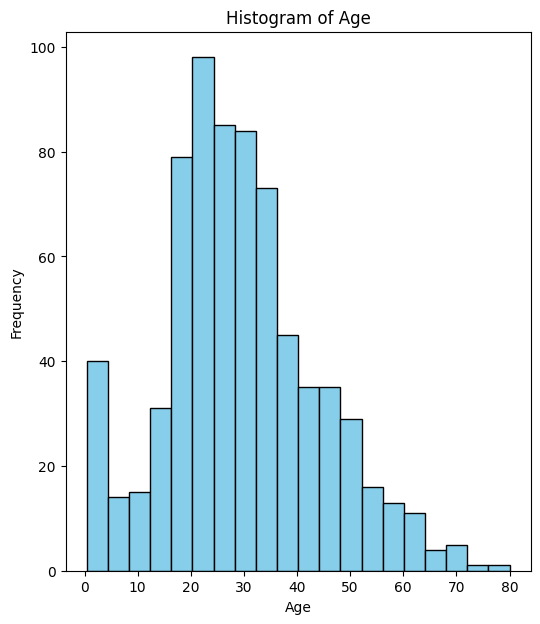

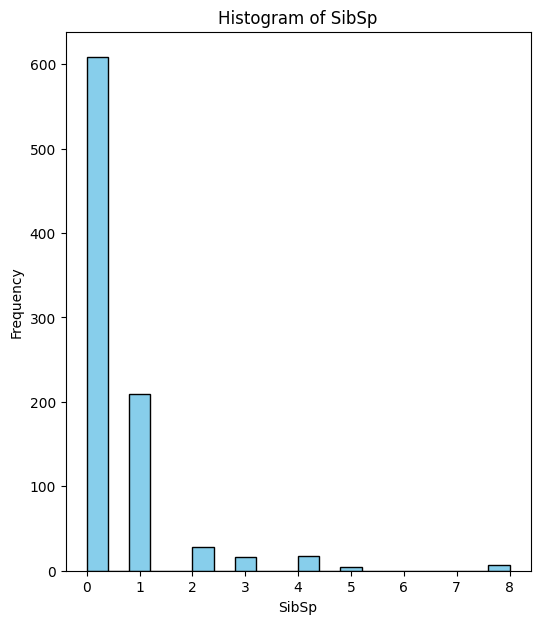

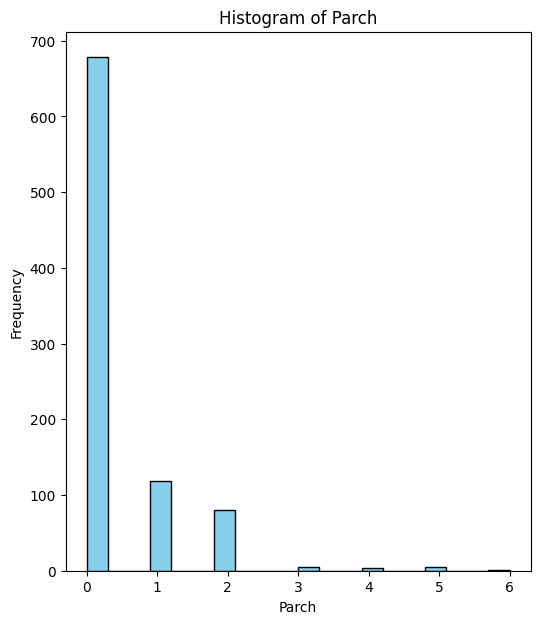

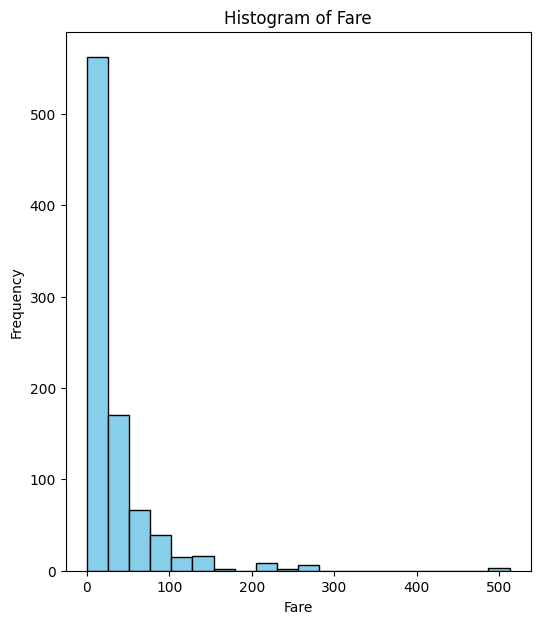

In [14]:
# using matplotlib to visualize Numerical data types

for column in df.select_dtypes(include=["int64", "float64"]).columns:
    plt.figure(figsize = (6,7))
    plt.hist(df[column], bins=20, color= "skyblue", edgecolor = "black")
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

Data Cleaning

In [18]:
# Checking for missing values with percentages

missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

print("Missing Values Summary")
print(missing_percent)

Missing Values Summary
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


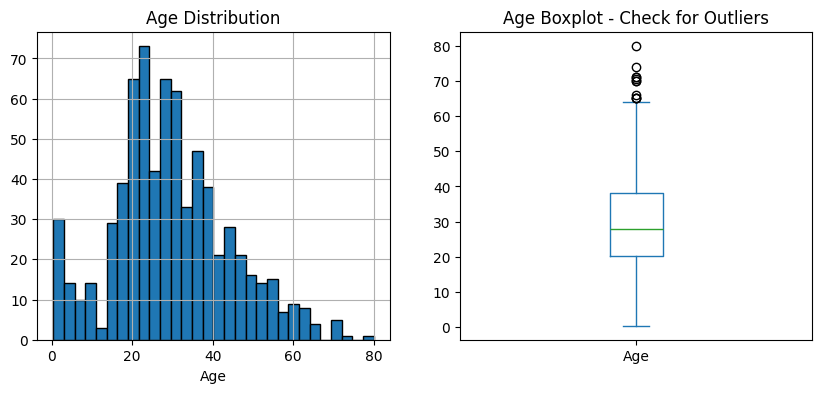

COMPARING MEAN vs MEDIAN
Mean Age:     29.70 years
Median Age:   28.00 years
Skewness:     0.39
Difference:   1.70 years

CHOSEN METHOD: MEAN

Reason: The skewness is 0.39 (approximately normal)
Data is fairly symmetric, so mean is appropriate.

VERIFICATION
Missing Age values before: 177
Missing Age values after: 0
Value used for imputation: 29.70 years

✓ Age imputation completed successfully!


In [19]:
import matplotlib.pyplot as plt

# Visualize Age distribution
plt.figure(figsize=(10, 4))

# Histogram
plt.subplot(1, 2, 1)
df['Age'].hist(bins=30, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')

# Boxplot
plt.subplot(1, 2, 2)
df['Age'].plot(kind='box')
plt.title('Age Boxplot - Check for Outliers')
plt.show()

# Calculate statistics
mean_age = df['Age'].mean()
median_age = df['Age'].median()
skewness = df['Age'].skew()

print("="*60)
print("COMPARING MEAN vs MEDIAN")
print("="*60)
print(f"Mean Age:     {mean_age:.2f} years")
print(f"Median Age:   {median_age:.2f} years")
print(f"Skewness:     {skewness:.2f}")
print(f"Difference:   {abs(mean_age - median_age):.2f} years")

# Decision Logic for Imputation
print("\n" + "="*60)
if skewness > 0.5:
    print("CHOSEN METHOD: MEDIAN")
    print(f"\nReason: The skewness is {skewness:.2f} (positive/right-skewed)")
    print("This means there are outliers pulling the mean higher.")
    print("Median is more robust and represents typical passenger age better.")
    chosen_value = median_age
elif skewness < -0.5:
    print("CHOSEN METHOD: MEDIAN")
    print(f"\nReason: The skewness is {skewness:.2f} (negative/left-skewed)")
    print("This means there are outliers pulling the mean lower.")
    print("Median is more robust and represents typical passenger age better.")
    chosen_value = median_age
else:
    print("CHOSEN METHOD: MEAN")
    print(f"\nReason: The skewness is {skewness:.2f} (approximately normal)")
    print("Data is fairly symmetric, so mean is appropriate.")
    chosen_value = mean_age

# Impute missing values
df['Age'].fillna(chosen_value, inplace=True)

# Verify
print("\n" + "="*60)
print("VERIFICATION")
print("="*60)
print(f"Missing Age values before: 177")
print(f"Missing Age values after: {df['Age'].isnull().sum()}")
print(f"Value used for imputation: {chosen_value:.2f} years")
print("\n✓ Age imputation completed successfully!")

In [20]:
# Handle Missing Cabin Values

# Check how much data is missing
missing_cabin = df['Cabin'].isnull().sum()
total = len(df)
percent_missing = (missing_cabin / total) * 100

print(f"Missing Cabin values: {missing_cabin} out of {total}")
print(f"That's {percent_missing:.1f}% missing!")

# Decision: Drop the Cabin column because too much data is missing
print("\nDecision: Dropping Cabin column")
print("Reason: Over 77% of data is missing - too much to impute")

df.drop('Cabin', axis=1, inplace=True)

Missing Cabin values: 687 out of 891
That's 77.1% missing!

Decision: Dropping Cabin column
Reason: Over 77% of data is missing - too much to impute


In [21]:
# Handle Missing Embarked Values

# Check how many are missing
missing = df['Embarked'].isnull().sum()
print(f"Missing Embarked values: {missing}")

# Drop the rows with missing Embarked
df.dropna(subset=['Embarked'], inplace=True)

# Verify it worked
print(f"Missing Embarked now: {df['Embarked'].isnull().sum()}")
print(f"Rows removed: {missing}")
print("\nWhy drop? Only 2 missing values (less than 1%), so it's fine to remove them.")

Missing Embarked values: 2
Missing Embarked now: 0
Rows removed: 2

Why drop? Only 2 missing values (less than 1%), so it's fine to remove them.


After Cleaning

In [23]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C
